<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Imports](#imports)
- [Architectural and Performance Decisions](#architectual-and-performance-decisions)
- [Complex Network Feature Engineering](#complex-network-feature-engineering)
- [Initial Data Dictionary](#initial-data-dictionary)
- [Statistical and Associative Data Exploration](#statistical-and-associative-data-exploration)
    - [Explore edge_weight](#explore-edge_weight)
    - [Explore is_star_graph](#explore-is_star_graph)
    - [Explore is_chain_graph](#explore-is_chain_graph)
    - [Explore is_bridge_link](#explore-is_bridge_link)
    - [Explore graph_id](#explore-graph_id)
    - [Explore baseline_edge_weight_ratio](#explore-baseline_edge_weight_ratio)
    - [Explore baseline_edge_weight_zscore](#explore-baseline_edge_weight_zscore)
    - [Explore eigen_1](#explore-eigen_1)
    - [Explore eigen_2](#explore-eigen_2)
    - [Explore v1_src](#explore-v1_src)
    - [Explore v2_src](#explore-v2_src)
    - [Explore src_pagerank](#explore-src_pagerank)
    - [Explore dst_pagerank](#explore-dst_pagerank)
    - [Explore global_convergence_steps](#explore-global_convergence_steps)
    - [Explore node_convergence_steps](#explore-node_convergence_steps)
    - [Explore spectral_gap](#explore-spectral_gap)
- [Final Data Dictionary](#final-data-dictionary)

</div>

### ORIENTATION:

This file is intended to make decisions regarding the implementation of mathematic Complex Network ideas as well as their implementation into the 'NF-UQ-NIDS-v2 Network Intrusion Detection Dataset' and exploration of these newly engineered features.  Given the nature of complex networks reliance on matrix manipulation, analysis of graph generation time and matrix computation between NetworkX and iGraph will be the fundamental determining factors for expediency.

---

### IMPORTANT NOTE:

The nature of the dataset produces a **NON-COMPLETE** graph **WITHOUT** timestamps.  For this reason, to create a complete graph, we will have to analyze each complete sub-graph independently and will attempt to create a directed and weighted graph to derive the most information as possible since geographic information may not exist in the dataset (Cases of a star graph).  This fundamentally will change how we derive matricies, eigenvalues/eigenvectors, convergence steps, and PageRank.  Thankfully, both NetworkX and iGraph have multiple functions to handle most complex network tasks (Though I haven't personally explored all the source code, so whether or not they adhere to the fundamental mathematics derived is up in the air, but they seem to work!).

---

### SUMMARY:

- Architectural and Performance Decisions
    - We will create a directed and weighted graph by:
        1. Group `ipv4_src_addr`
        2. Group `ipv4_dst_addr`
        3. Group `target` 
        4. Engineer continuous feature `edge_weight` (based on `explore_normal_data.ipynb`'s findings) with `in_bytes, out_bytes, duration_in`
        5. Engineer binary features `is_star_graph, is_chain_graph, is_bridge_link` using diameter for the first two and iGraph's `bridges()` function
        6. Drop all other information as they are unnecessary for complex network feature engineering at this point
    - NetworkX is faster at graph generation and iGraph is faster at matrix manipulation.  For this reason, iGraph will be used for complex network manipulation and feature engineering.
- Complex Network Feature Engineering
    - Filtered original dataset down to grouped source then destination ips and derived features denoted in the *Architectural and Performance Decisions* section of this notebook
    - Removed 0.0.0.0 IPs since they don't provide any useful insight (Noise)
    - Engineered:
        - `graph_id`
        - `baseline_edge_weight_ratio`
        - `baseline_edge_weight_zscore`
        - `eigen_1`
        - `eigen_2`
        - `v1_src`
        - `v2_src`
        - `src_pagerank`
        - `dst_pagerank`
        - `global_convergence_steps`
        - `node_convergence_steps`
        - `spectral_gap`
- Initial Data Dictionary
    - The dataset used is the `clean_complex.parquet` which is a grouped version and altered version of `clean_short.parquet` specifically for complex network purposes
    - Rows: 241,361
    - Columns: 19
    - Target: `attack` (21 Unique tags, distribution visualized below data dictionary)
    - Note that the data is now **highly** imbalanced with over 99% entries being `benign` as opposed to the original 33%.  This is likely because of grouping, but may prove an even stronger association of complex network capabilities during model evaluation if the complex network version performs better
- Statistical and Associative Data Exploration
    - Initial Removal of Columns For Analysis
        - Data Leakage
            - source_ip
            - destination_ip
        - Target Variable
            - attack
            - target
    - Note that all features except for `is_chain_graph` and `is_star_graph` are statistically significant.  The exceptions are to be expected since this was created as additional classification to differentiate and group respective information for model training.  Besides this, it is interesting that statistical testing passed given that the dataset is highly imbalanced with over 99% entries as `benign` attacks which means that even with this very large imbalance, there's something mathematically distinct about all the information that is differentiable from `benign`
    - Post Removal of Columns
        - None, everything will be kept for now since the experiment is to observe what complex network ideology has to offer for machine learning algorithms
- Final Data Dictionary
    - Normalized and scaled columns and created `datasets/prepared_complex.parquet`
    - Rows: 241,361
    - Columns: 20
    - `attack` and `target` are the respective categorical and numerical ID target feature


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [1]:
# Largely for re-usable visuals, statistics, and helper functions
import explore_normal_data as eND

# Necessary for Complex Network related functions
import explore_complex_networks as eCN

# Databasing
import pandas as pd

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Architectural and Performance Decisions

- [Back to Table of Contents](#table-of-contents)

</div>

##### SUMMARY

- We will create a directed and weighted graph by:
    1. Group `ipv4_src_addr`
    2. Group `ipv4_dst_addr`
    3. Group `target` 
    4. Engineer continuous feature `edge_weight` (based on `explore_normal_data.ipynb`'s findings) with `in_bytes, out_bytes, duration_in`
    5. Engineer binary features `is_star_graph, is_chain_graph, is_bridge_link` using diameter for the first two and iGraph's `bridges()` function
    6. Drop all other information as they are unnecessary for complex network feature engineering at this point
- NetworkX is faster at graph generation and iGraph is faster at matrix manipulation.  For this reason, iGraph will be used for complex network manipulation and feature engineering.

---

##### Dataset Takeaways

- Geometric Description
    - Is disconnected
    - Generally made up of star graphs, but there are more connected and longer paths
    - There exists benign connecting to benign/malicious nodes and malicious connecting to malicious
- Because of the above, we will assign a `graph_id` to every entry to denote what entry belongs to which **COMPLETED GRAPH** so that complex network implementation is cleaner
- Additionally, because star graphs makeup the general structure of most, we will direct and weight edges to embed the most information as possible between node interactions since geography doesn't have a whole lot to offer at first glance.  From the `explore_normal_data.ipynb`, we will weight the edges by aggregating `in_bytes, out_bytes, duration_in` and direct the edges simply with `ipv4_src_addr` and `ipv4_dst_addr`.  To catch any repeat connections, we will group first by the `ipv4_src_addr`, then group by the `ipv4_dst_addr`, then by `target` to catch repeat connections that were benign but malicious in another instance
- From this grouping logic, we will be reducing the entries by grouping the source then the destination ips.  Additionally, we will be engineering a new continuous feature `edge_weight` where all other features are dropped as they are useless in this case
- In terms of this basic geography of the network, we will engineer three binary features for potential ML/NN training and any standalone node (diam=1) will be removed:
    - `is_star_graph` (0,1)
    - `is_chain_graph` (0,1)
    - `is_bridge_link` (0,1)

---

##### iGraph vs. NetworkX

- Timing Comparisons
    - iGraph Faster:
        - Adj Matrix Generation
        - Matrix Multiplication Generation
    - NetworkX Faster:
        - Graph Generation
        

In [2]:
# Load in the dataset
df = pd.read_parquet('datasets/clean_short.parquet')

Graph Status: Not Connected


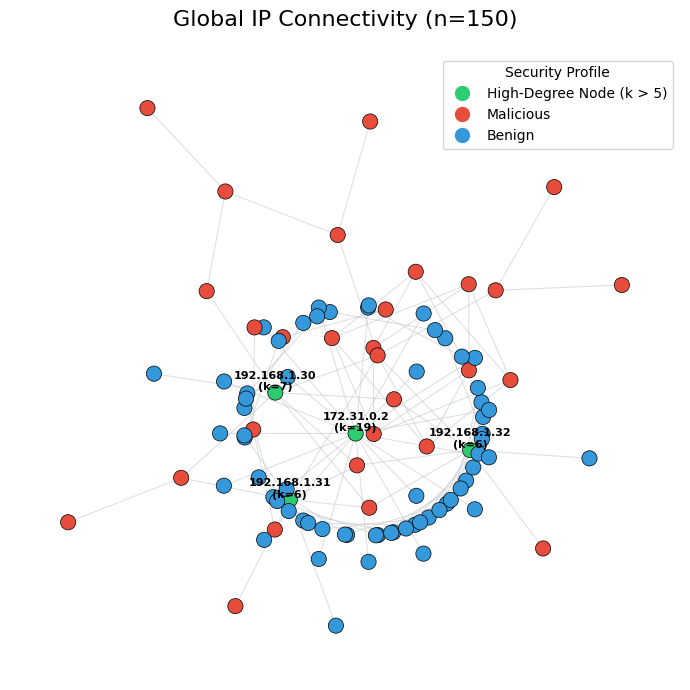

In [3]:
# Visualize the original dataset graph
eCN.vis_original_overall_graph(df)

**Key Takeaway:** The graph is not connected, thus we will need to try and group all the connected graphs in order to properly apply complex network ideology

---

Verified Topology: Star (Diam=2)


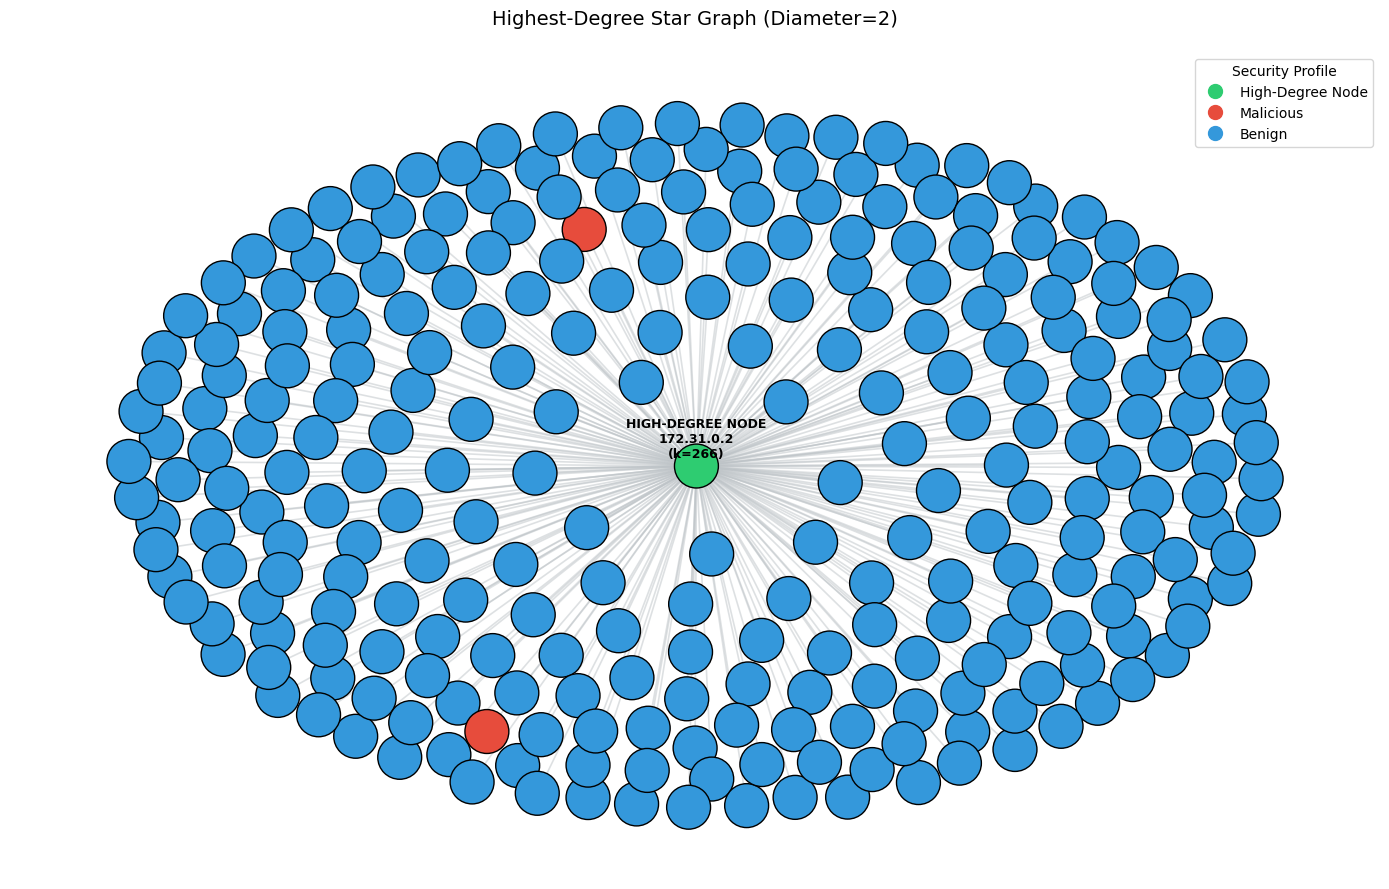

In [4]:
# Visualize the highest-degree star graph
eCN.vis_original_star_graph(df)

**Key Takeaway:** Many of the complete graphs are star graphs, thus we need to determine something about the edge that may deliniate between a benign and malicious connection.  Thus we will create a directed and weighted graph using `in_bytes, out_bytes, duration_in`

---

========== START GRAPH GENERATION COMPARISON ==========


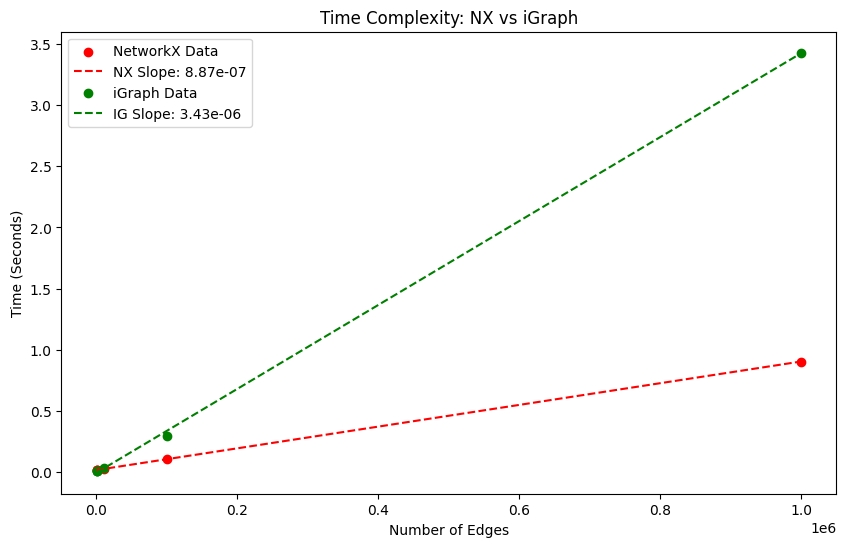

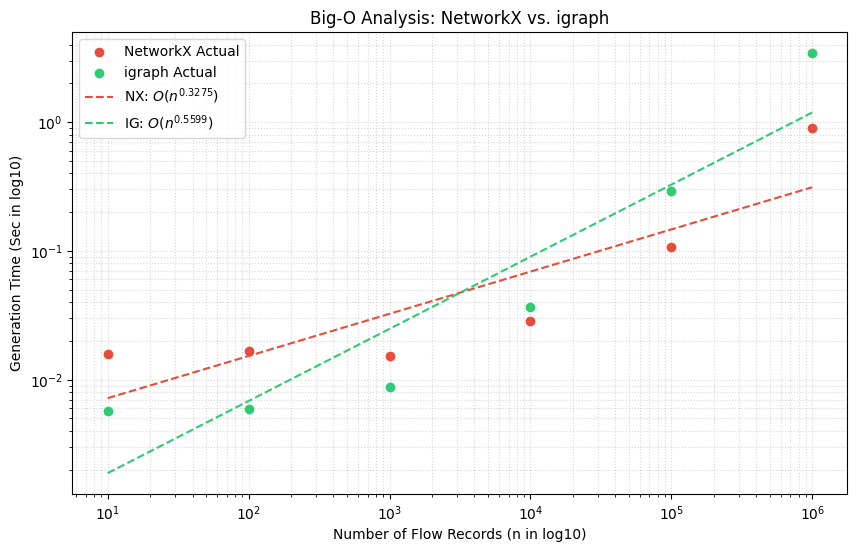

========== START ADJACENCY MATRIX GENERATION COMPARISON ==========


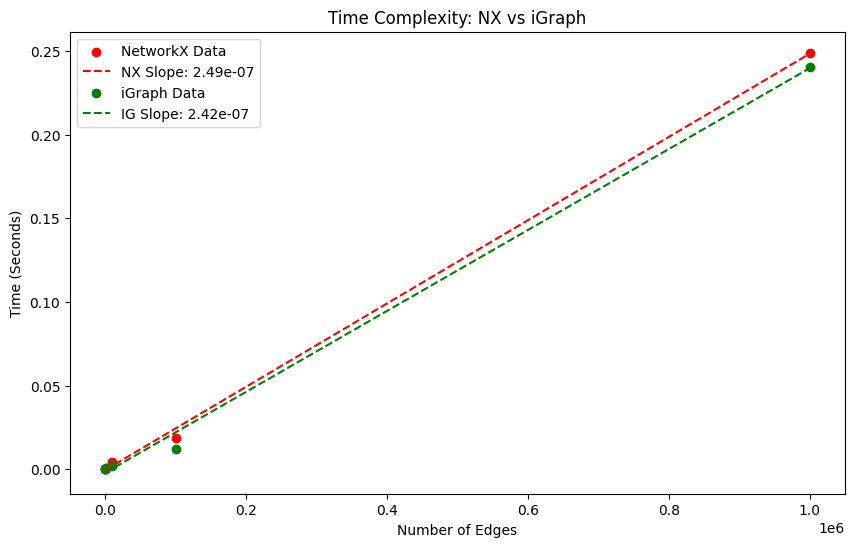

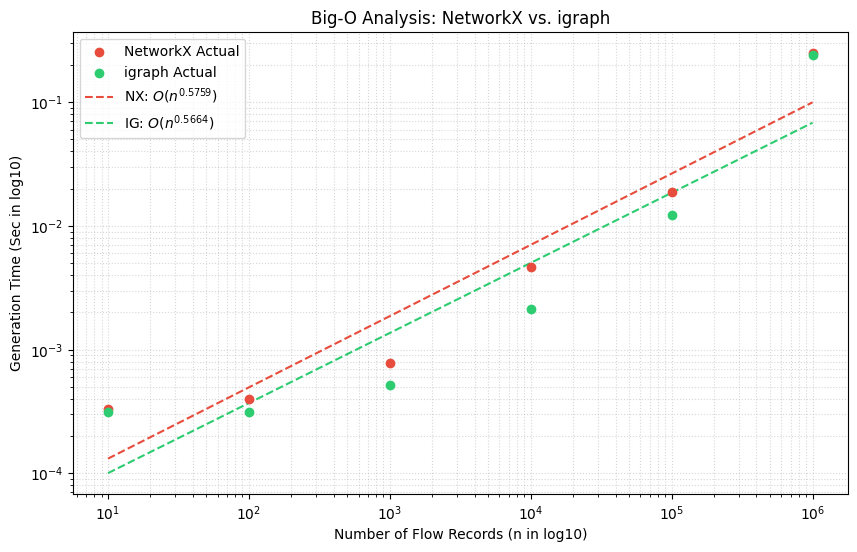

========== START MATRIX MULTIPLICATION GENERATION COMPARISON ==========


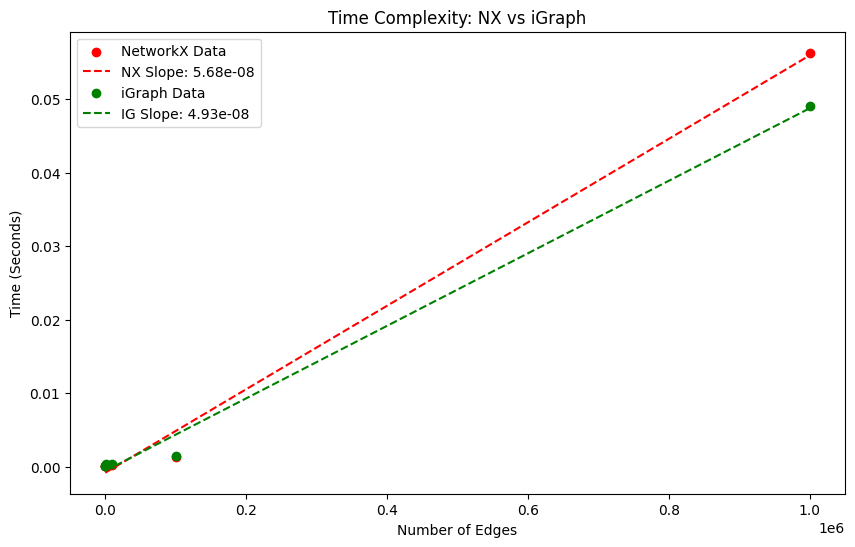

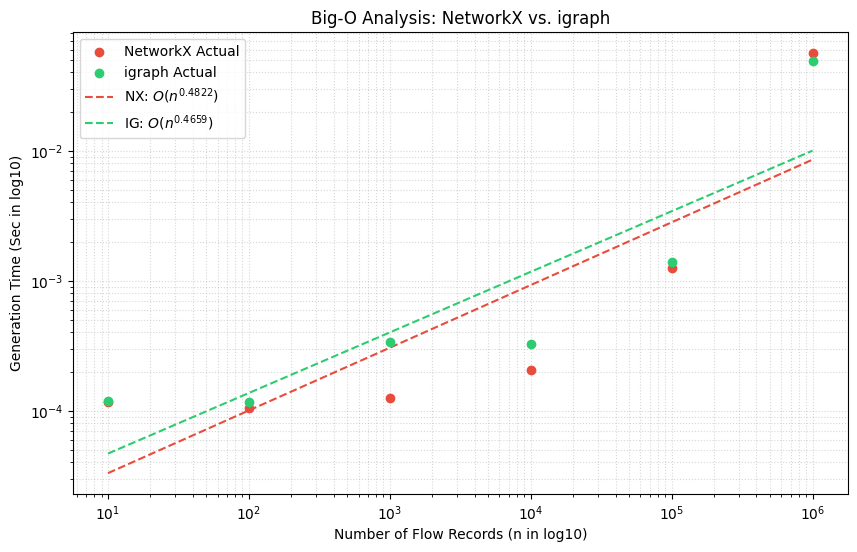

In [5]:
# Visualize graph, adjacency matrix, and matrix multiplication generation timings
eCN.batch_generate_timing(df)

**Key Takeaway:** iGraph seems to be overall superior with computation which is the majority of complex network feature engineering, so we will use iGraph for this reason

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Complex Network Feature Engineering

- [Back to Table of Contents](#table-of-contents)

</div>

### SUMMARY

- Filtered original dataset down to grouped source then destination ips and derived features denoted in the *Architectural and Performance Decisions* section of this notebook
- Removed 0.0.0.0 IPs since they don't provide any useful insight (Noise)
- Engineered:
    - `graph_id`
    - `baseline_edge_weight_ratio`
    - `baseline_edge_weight_zscore`
    - `eigen_1`
    - `eigen_2`
    - `v1_src`
    - `v2_src`
    - `src_pagerank`
    - `dst_pagerank`
    - `global_convergence_steps`
    - `node_convergence_steps`
    - `spectral_gap`

In [3]:
# Initially reduce the dataset from above specifications
initial_reduced_df = eCN.generate_reduced_graph_df(df)

datasets/initial_complex.parquet not detected. Attempting to create datasets/initial_complex.parquet...
Successfully created datasets/initial_complex.parquet!


---

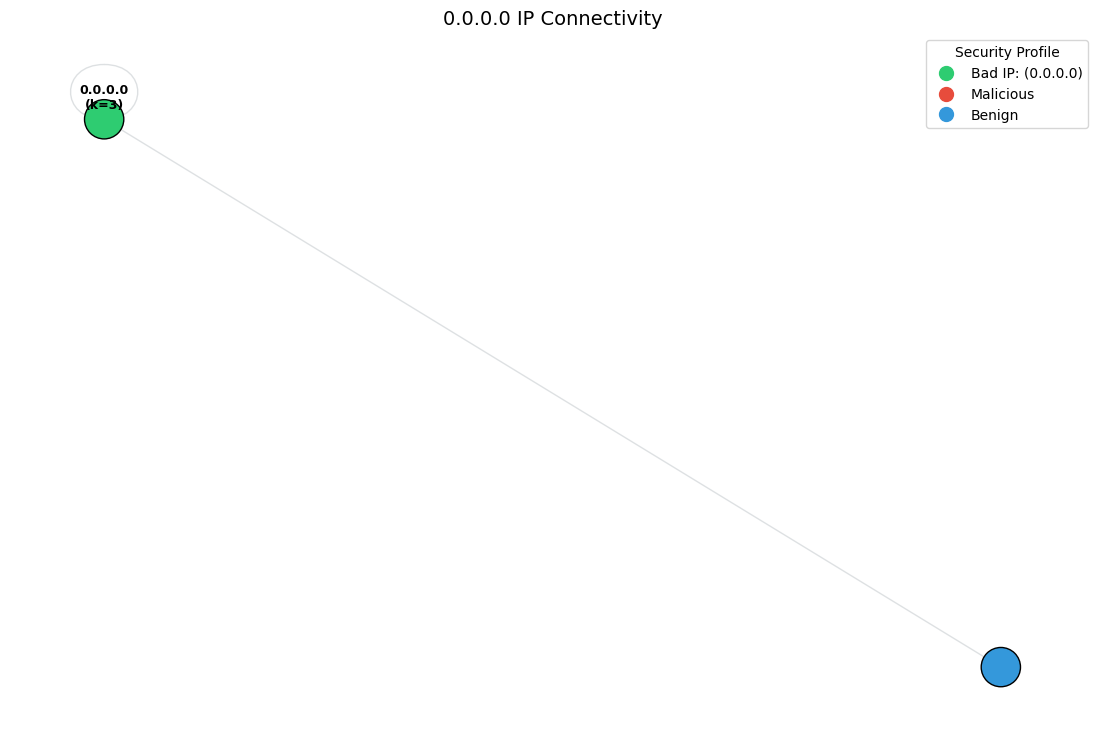

In [4]:
# Visualize 0.0.0.0 graph to determine its significance
eCN.vis_bad_ips(initial_reduced_df)

In [3]:
# Remove 0.0.0.0 IPs
initial_reduced_df = eCN.remove_bad_ips(initial_reduced_df)

Removed 2 rows containing 0.0.0.0.


**Key Takeaway:** 0.0.0.0 IPs will be removed since they hold nothing of importance (It also has self-loops which are generally not ideal for complete graphs)

---

##### Engineer `graph_id`

In [4]:
# Create the graph IDs for every entry
initial_reduced_df = eCN.generate_graph_ids(initial_reduced_df)

---

##### Engineer `baseline_edge_weight_ratio` and `baseline_edge_weight_zscore` from `attack==benign` as a baseline

In [5]:
# Create the edge_weight ratio/zscore based on the benign entries as the baseline
initial_reduced_df = eCN.generate_intensity_and_zscore(initial_reduced_df)

---

##### Engineer `eigen_1, eigen_2, v1_src, v2_src, src_pagerank, dst_pagerank, global_convergence_steps, node_convergence_steps, spectral_gap`

In [6]:
# Get the complex network information
initial_reduced_df = eCN.generate_complex_network_information(initial_reduced_df)

---

##### Create `datasets/clean_complex.parquet`

In [7]:
# Create cleaned dataset
initial_reduced_df.to_parquet('datasets/clean_complex.parquet')

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Initial Data Dictionary

- [Back to Table of Contents](#table-of-contents)

</div>

In [8]:
# Read in the dataset
clean_df = pd.read_parquet('datasets/clean_complex.parquet')

The dataset used is the `clean_complex.parquet` which is a grouped version and altered version of `clean_short.parquet` specifically for complex network purposes

- Rows: 241,361
- Columns: 18
- Target: `attack` (21 Unique tags, distribution visualized below data dictionary)
- Note that the data is now **highly** imbalanced with over 99% entries being `benign` as opposed to the original 33%.  This is likely because of grouping, but may prove an even stronger association of complex network capabilities during model evaluation if the complex network version performs better

| Feature Name | Dtype | Example | Description |
| :--- | :--- | :--- | :--- |
| **source_ip** | `str` | 0.147.57.10 | Unique identifier for the originating network node. |
| **destination_ip** | `str` | 192.168.1.194 | Unique identifier for the receiving network node. |
| **edge_weight** | `float64` | 840.0 | Raw magnitude of traffic weighting the connection. |
| **is_star_graph** | `int64` | 0, 1 | Boolean flag: 1 if the flow belongs to a hub-and-spoke topology. |
| **is_chain_graph** | `int64` | 1, 0 | Boolean flag: 1 if the flow is part of a sequential multi-hop path. |
| **is_bridge_link** | `int64` | 1, 0 | Boolean flag: 1 if this edge connects two distinct graph islands. |
| **attack** | `str` | benign, ddos | Ground-truth label for security classification. |
| **graph_id** | `int64` | 0, 1, 2 | Unique identifier for the discrete graph island. |
| **baseline_edge_weight_ratio** | `float64` | 0.024786 | Intensity ratio relative to benign topology averages. |
| **baseline_edge_weight_zscore** | `float64` | -0.019630 | Statistical deviation of flow weight from the benign mean. |
| **eigen_1** | `float64` | 654558925.7 | Principal eigenvalue; total structural energy/traffic mass. |
| **eigen_2** | `float64` | 652123263.7 | Second eigenvalue; indicates secondary clusters or hubs. |
| **v1_src** | `float64` | 8.57e-19 | Source component in the first eigenvector (energy hierarchy). |
| **v2_src** | `float64` | 4.45e-19 | Source component in the second eigenvector (cluster role). |
| **src_pagerank** | `float64` | 0.009910 | Influence score identifying source popularity in the graph. |
| **dst_pagerank** | `float64` | 0.003442 | Influence score identifying destination IP as a traffic sink. |
| **global_convergence_steps** | `float64` | 3115.0 | The global number of steps before convergence for a specific graph ID |
| **node_convergence_steps** | `float64` | 2.0 | The node specific number of steps before convergence within a specific graph ID |
| **spectral_gap** | `float64` | 2435661.9 | Absolute difference between eigenvalues; measures centralization. |

/Users/manupfool/Desktop/University_of_Denver/inprogress_courses/COMP3703/final/explore_normal_data.py:468: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.values, y=labels, palette='viridis')


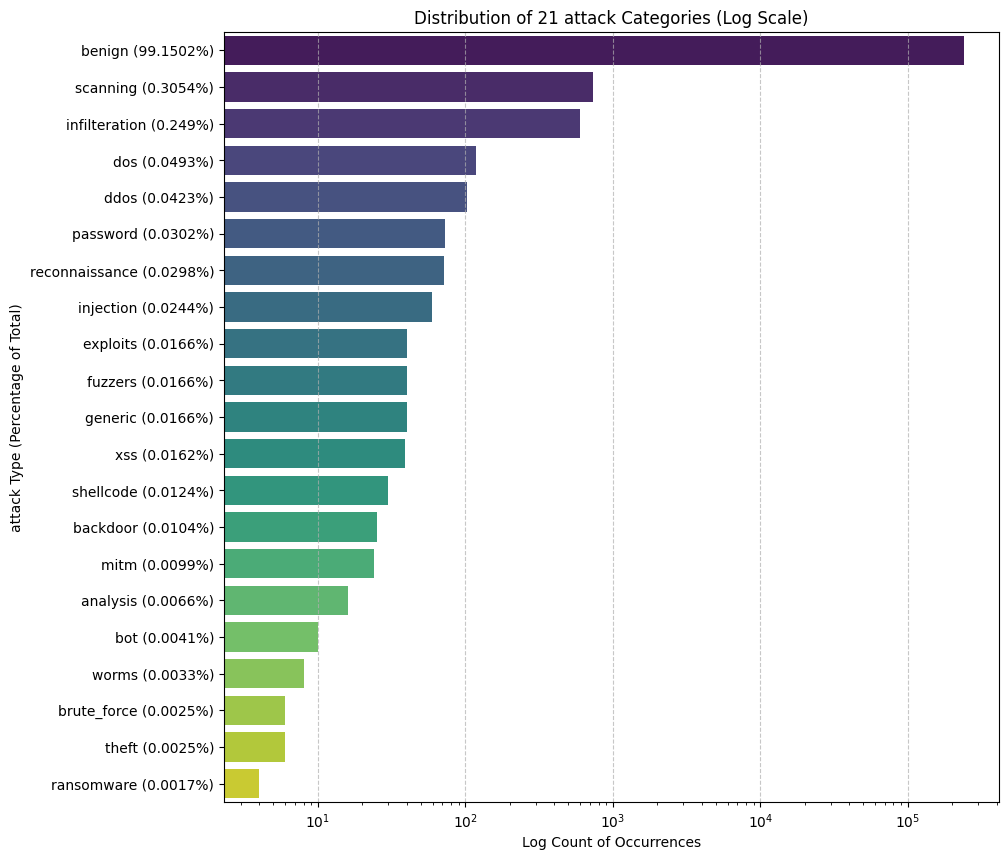

In [27]:
# Visualize target distribution
eND.vis_target_distribution(clean_df)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Statistical and Associative Data Exploration

- [Back to Table of Contents](#table-of-contents)

</div>

### SUMMARY:

- Initial Removal of Columns For Analysis
    - Data Leakage
        - source_ip
        - destination_ip
    - Target Variable
        - attack
        - target
- Note that all features except for `is_chain_graph` and `is_star_graph` are statistically significant.  The exceptions are to be expected since this was created as additional classification to differentiate and group respective information for model training.  Besides this, it is interesting that statistical testing passed given that the dataset is highly imbalanced with over 99% entries as `benign` attacks which means that even with this very large imbalance, there's something mathematically distinct about all the information that is differentiable from `benign`
- Analysis findings for every feature
    - edge_weight // KEEP // Minimal association, but for the sake of complex networks, this is necessary to differentiate node interactions
    - is_star_graph // KEEP // Zero association, but for the sake of complex networks, this is used to differentiate and group respective information
    - is_chain_graph // KEEP // Zero association, but for the sake of complex networks, this is used to differentiate and group respective information
    - is_bridge_link // KEEP // Minimal association, but for the sake of complex networks, this is used to denote nodes that will disconnect a complete graph
    - graph_id // KEEP // High association, but for the sake of complex networks, this is necessary to differentiate and group respective information
    - baseline_edge_weight_ratio // KEEP // Minimal association, but for the sake of complex networks, this is necessary to differentiate node interactions
    - baseline_edge_weight_zscore // KEEP // Minimal association, but for the sake of complex networks, this is necessary to differentiate node interactions
    - eigen_1 // KEEP // High association, but for the sake of complex networks, this is to denote the unique graph topology
    - eigen_2 // KEEP // High association, but for the sake of complex networks, this is to denote the unique graph topology
    - v1_src // KEEP // Minimal association, but for the sake of complex networks, this is to denote the unique node relation to the overall graph topology
    - v2_src // KEEP // Minimal association, but for the sake of complex networks, this is to denote the unique node relation to the overall graph topology
    - src_pagerank // KEEP // Minimal association, but for the sake of complex networks, this is to denote the unique node relation to the overall graph topology
    - dst_pagerank // KEEP // Minimal association, but for the sake of complex networks, this is to denote the unique node relation to the overall graph topology
    - global_convergence_steps // KEEP // High association, but for the sake of complex networks, this is to denote the unique graph topology
    - node_convergence_steps // KEEP // Minimal association, but for the sake of complex networks, this is to denote unique node and graph relationships
    - spectral_gap // KEEP // High association, but for the sake of complex networks, this is to denote the unique graph topology
- Post Removal of Columns
    - None, everything will be kept for now since the experiment is to observe what complex network ideology has to offer for machine learning algorithms

---
##### Explore edge_weight

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- Minimal association
- Differentiates node interactions

edge_weight IS statistically significant with attack!
Statistic: 1351.4785
P-Val: 0.0000
P-Threshold: 0.0500



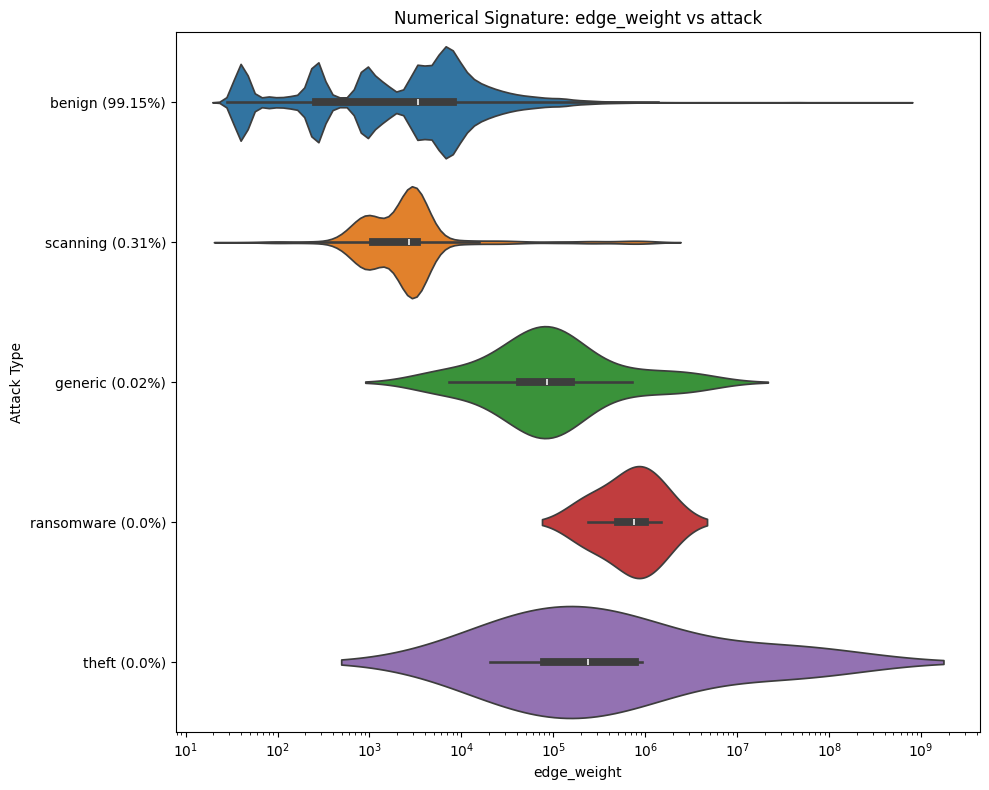

edge_weight has MINIMAL ASSOCATION with attack!


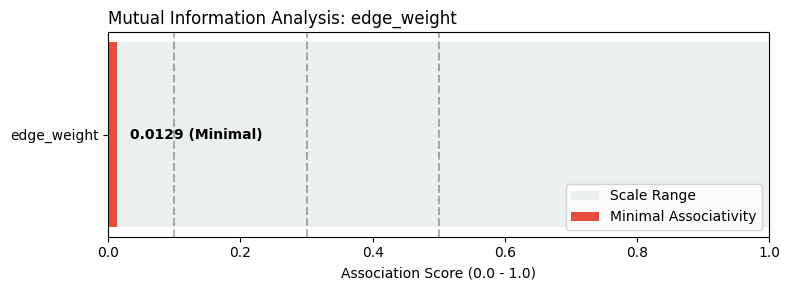

In [4]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'edge_weight')

---
##### Explore is_star_graph

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- Zero association
- Differentiate and groups respective information for training

is_star_graph IS NOT statistically significant with attack!
Statistic: 1.6554
P-Val: 1.0000
P-Threshold: 0.0500


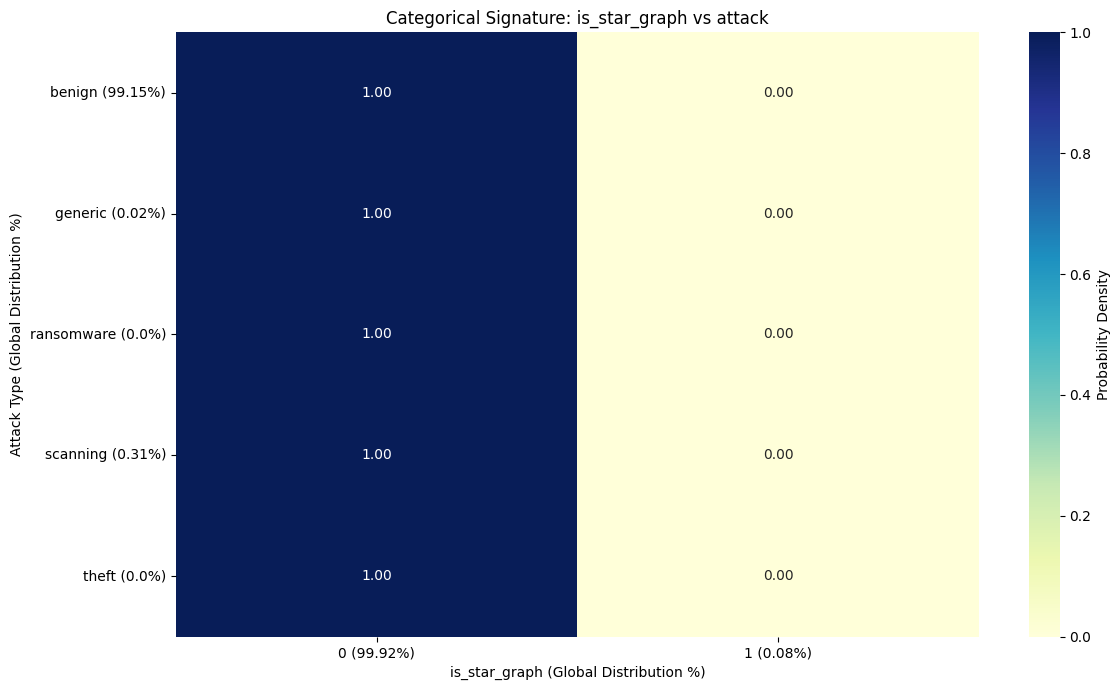

is_star_graph has MINIMAL ASSOCATION with attack!


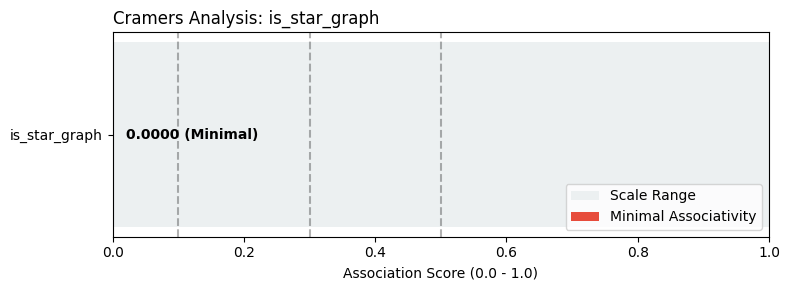

In [5]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'is_star_graph', is_object_feature=True)

---
##### Explore is_chain_graph

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- Zero association
- Differentiates and groups respective information for training

is_chain_graph IS NOT statistically significant with attack!
Statistic: 1.6554
P-Val: 1.0000
P-Threshold: 0.0500


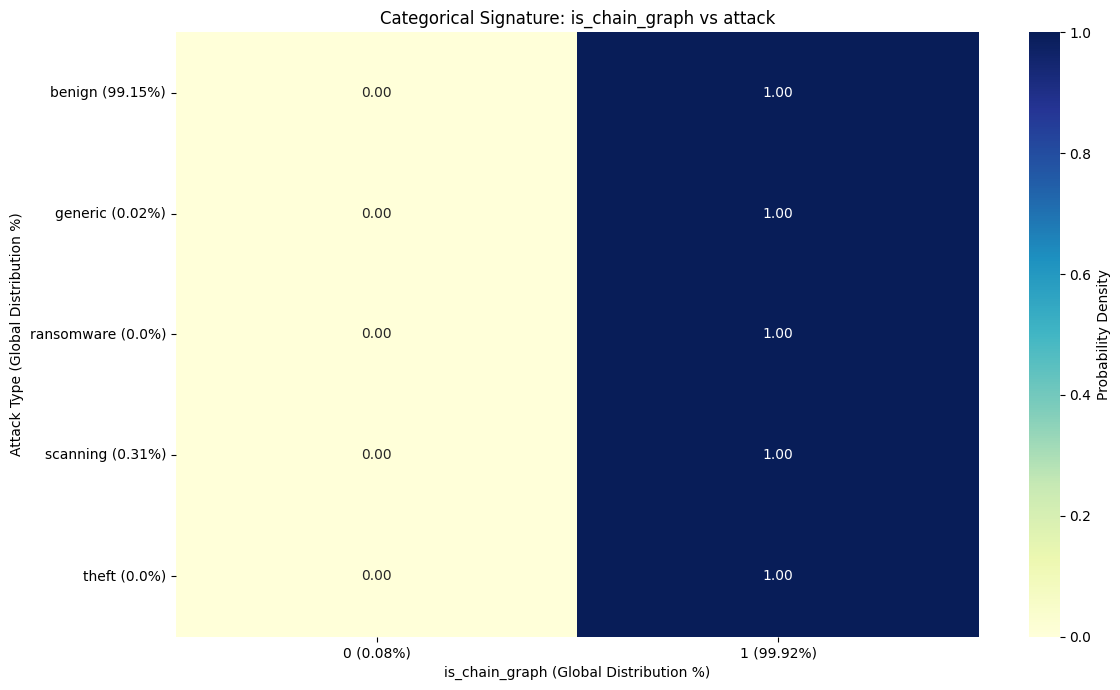

is_chain_graph has MINIMAL ASSOCATION with attack!


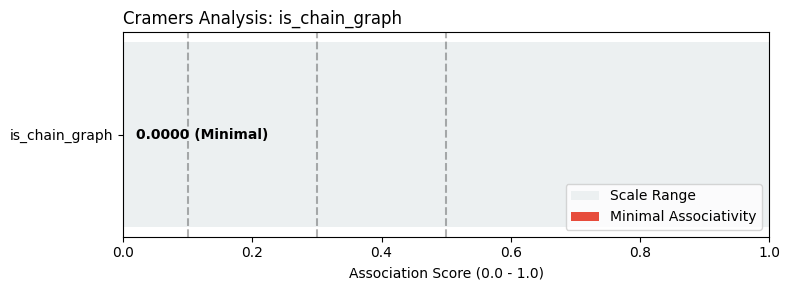

In [6]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'is_chain_graph', is_object_feature=True)

---
##### Explore is_bridge_link

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- Minimal association
- Differentiates and groups respective information for training

is_bridge_link IS statistically significant with attack!
Statistic: 236.7071
P-Val: 0.0000
P-Threshold: 0.0500


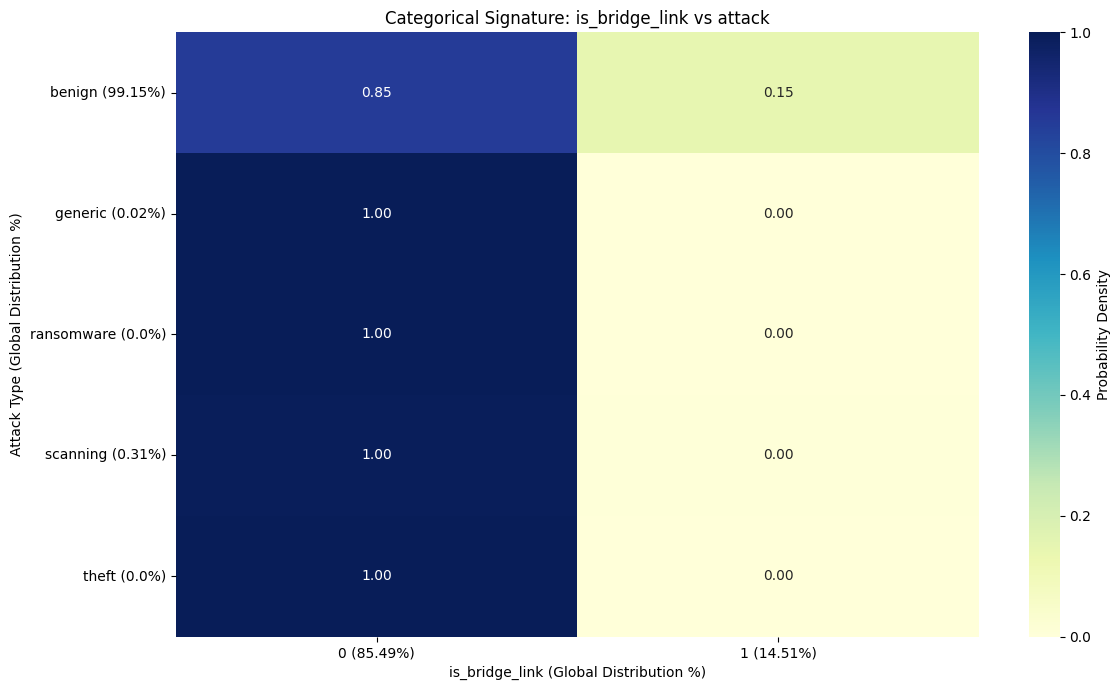

is_bridge_link has MINIMAL ASSOCATION with attack!


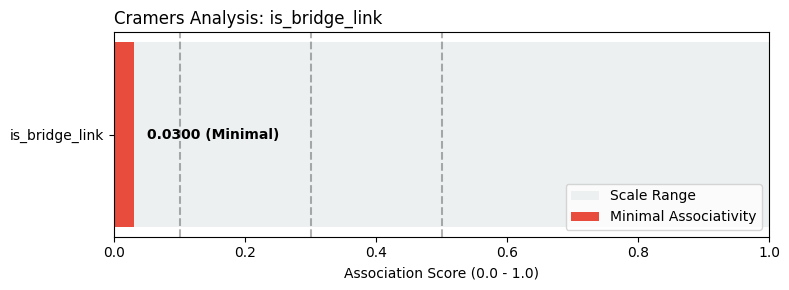

In [7]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'is_bridge_link', is_object_feature=True)

---
##### Explore graph_id

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association
- Differentiates and groups respective information for training

graph_id IS statistically significant with attack!
Statistic: 157012.1764
P-Val: 0.0000
P-Threshold: 0.0500


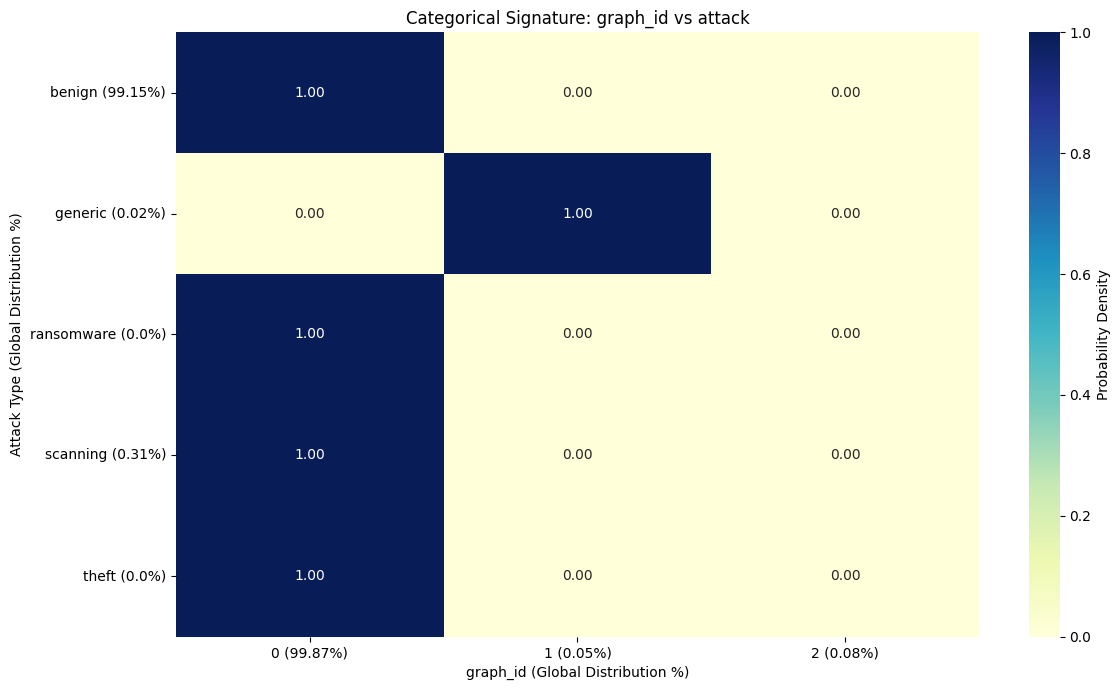

graph_id has HIGH ASSOCIATION with attack!


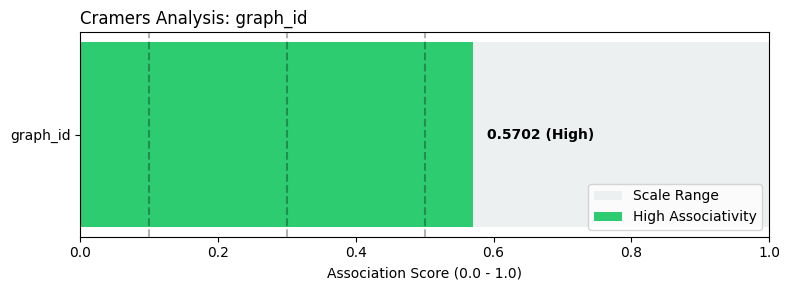

In [8]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'graph_id', is_object_feature=True)

---
##### Explore baseline_edge_weight_ratio

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- Minimal association
- Differentiates node interactions

baseline_edge_weight_ratio IS statistically significant with attack!
Statistic: 1354.2759
P-Val: 0.0000
P-Threshold: 0.0500



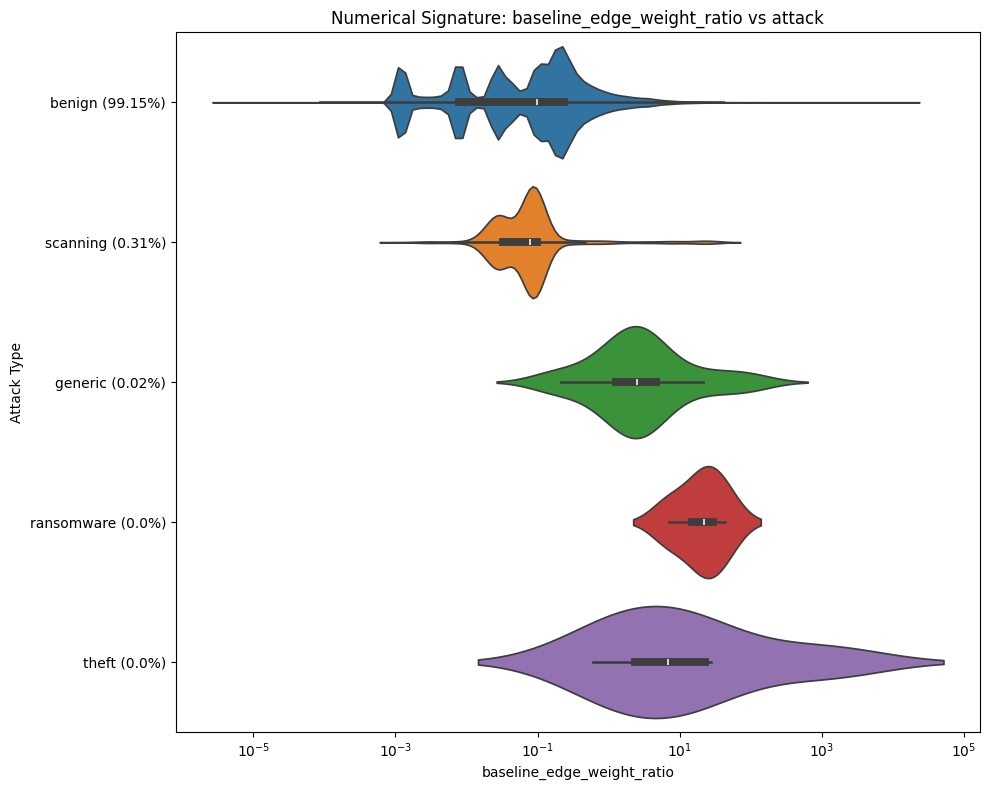

baseline_edge_weight_ratio has MINIMAL ASSOCATION with attack!


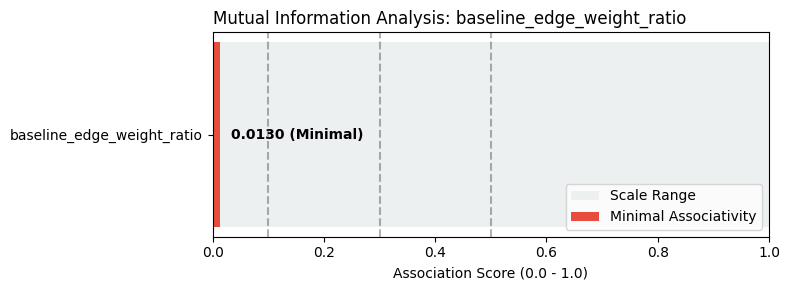

In [9]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'baseline_edge_weight_ratio')

---
##### Explore baseline_edge_weight_zscore

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- Minimal association
- Differentiates node interactions

baseline_edge_weight_zscore IS statistically significant with attack!
Statistic: 1353.4480
P-Val: 0.0000
P-Threshold: 0.0500



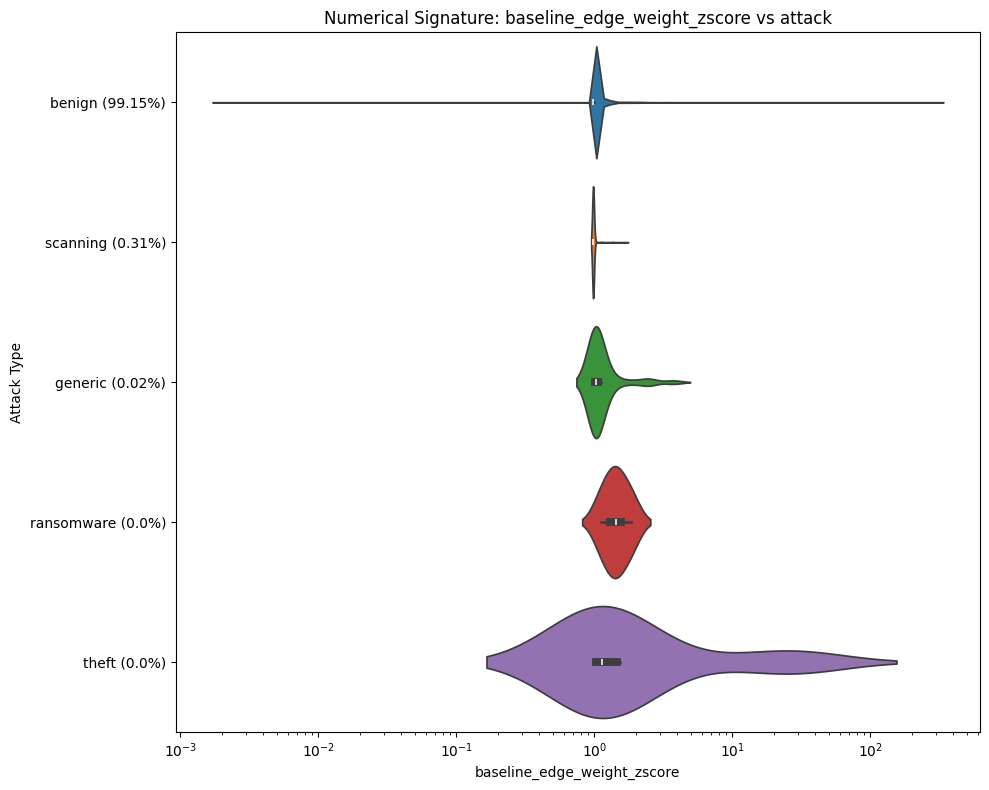

baseline_edge_weight_zscore has MINIMAL ASSOCATION with attack!


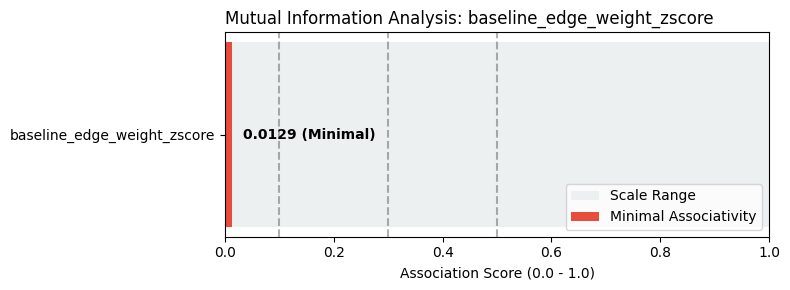

In [10]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'baseline_edge_weight_zscore')

---
##### Explore eigen_1

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association
- Denotes unique graph topology

eigen_1 IS statistically significant with attack!
Statistic: 157012.1764
P-Val: 0.0000
P-Threshold: 0.0500


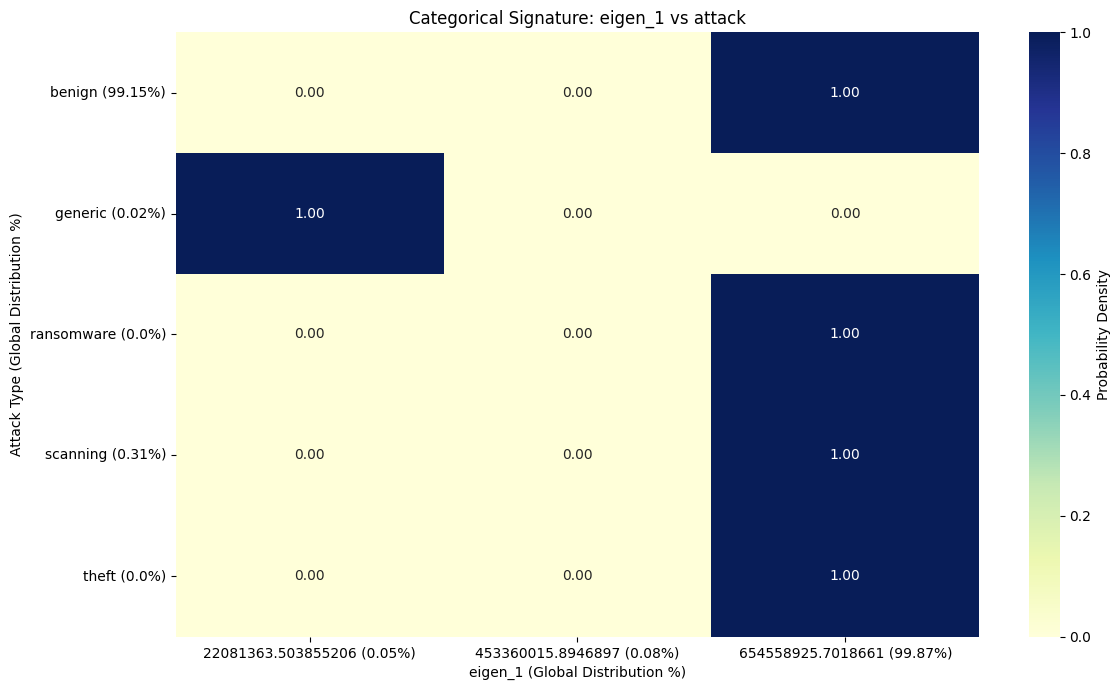

eigen_1 has HIGH ASSOCIATION with attack!


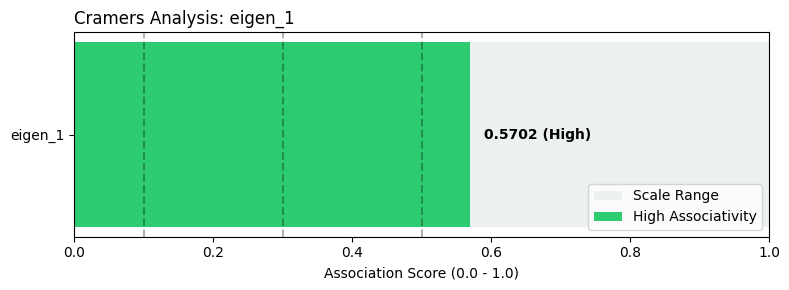

In [11]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'eigen_1', is_object_feature=True)

---
##### Explore eigen_2

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association
- Denotes unique graph topology

eigen_2 IS statistically significant with attack!
Statistic: 157012.1764
P-Val: 0.0000
P-Threshold: 0.0500


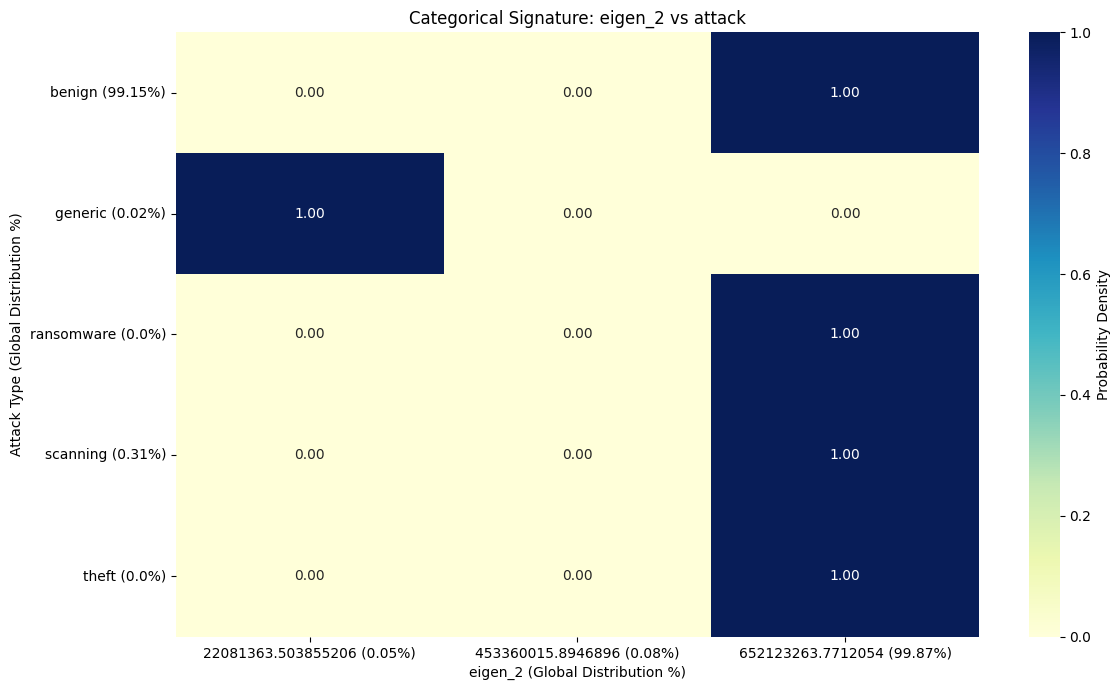

eigen_2 has HIGH ASSOCIATION with attack!


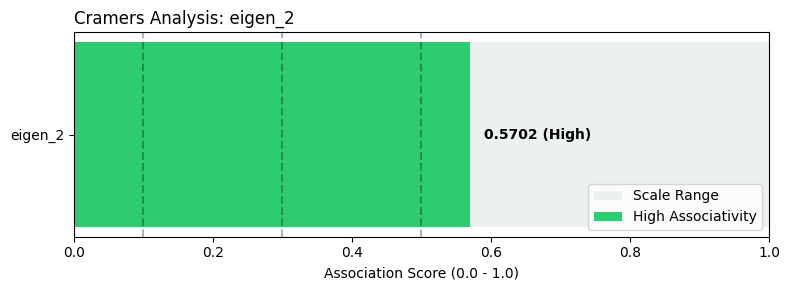

In [12]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'eigen_2', is_object_feature=True)

---
##### Explore v1_src

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- Minimal association
- Denotes unique node and graph interactions

v1_src IS statistically significant with attack!
Statistic: 4081.0039
P-Val: 0.0000
P-Threshold: 0.0500



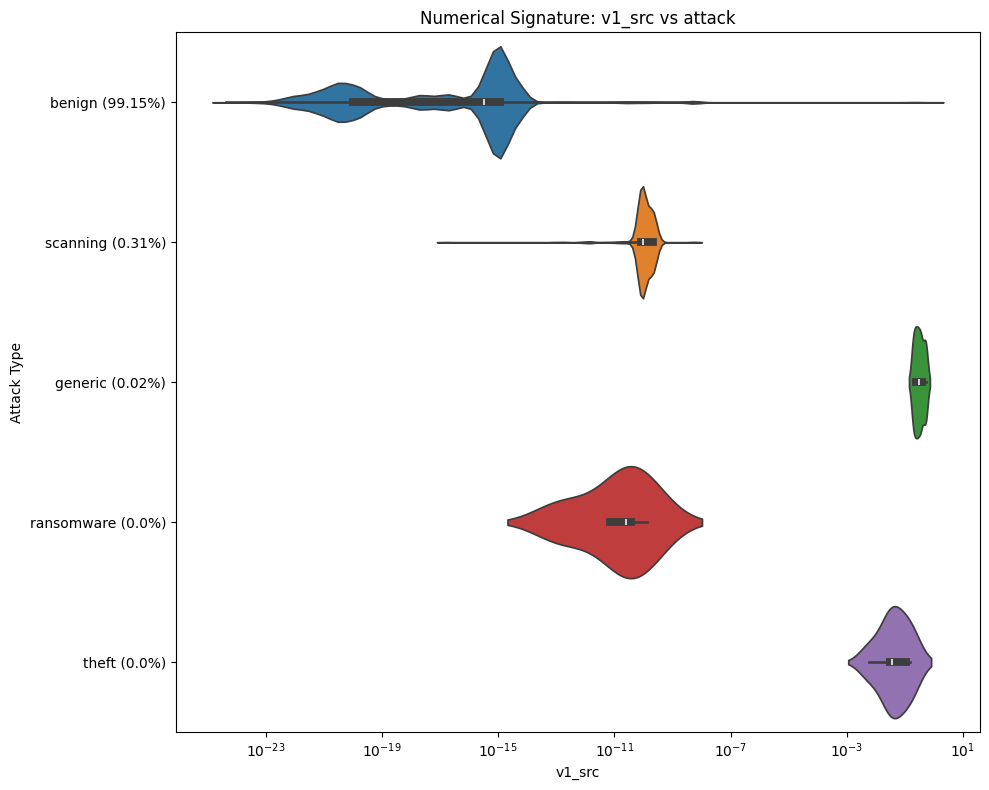

v1_src has MINIMAL ASSOCATION with attack!


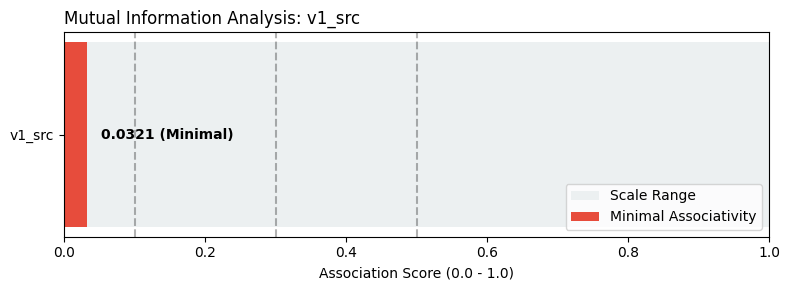

In [13]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'v1_src')

---
##### Explore v2_src

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- Minimal association
- Denotes unique node and graph interactions

v2_src IS statistically significant with attack!
Statistic: 4086.2586
P-Val: 0.0000
P-Threshold: 0.0500



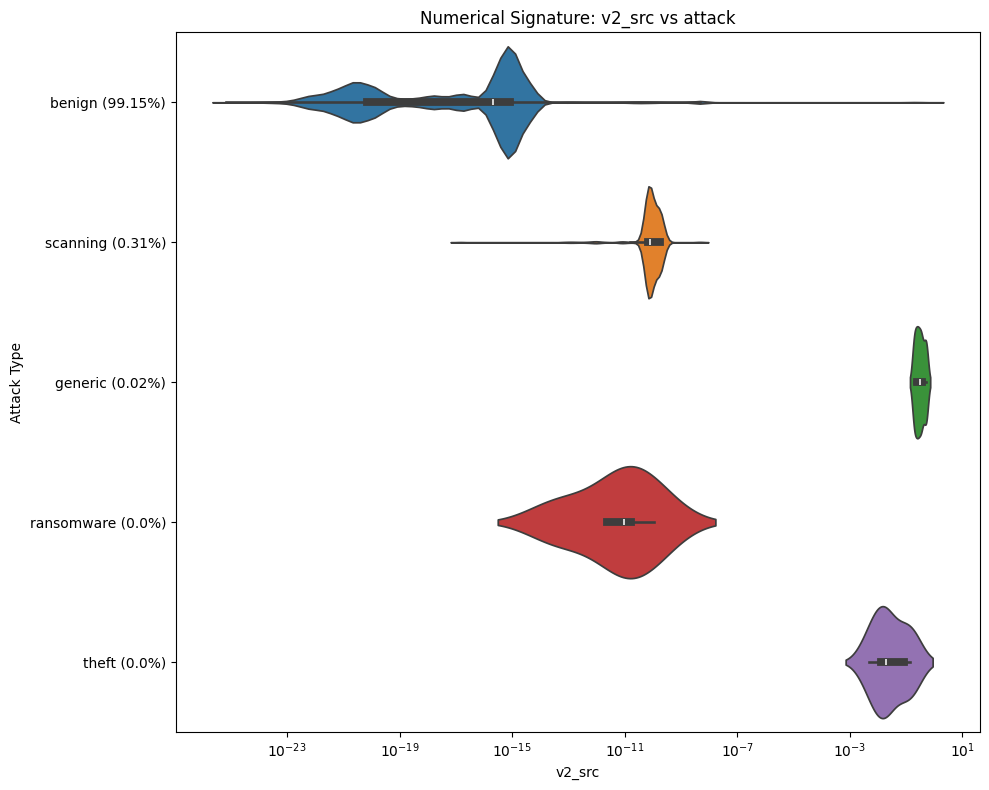

v2_src has MINIMAL ASSOCATION with attack!


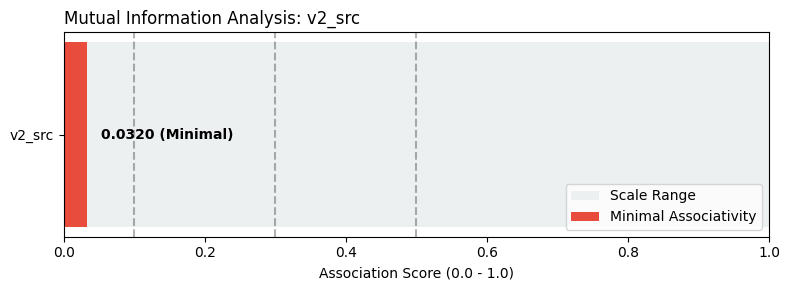

In [14]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'v2_src')

---
##### Explore src_pagerank

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- Minimal association
- Denotes unique node and graph interactions

src_pagerank IS statistically significant with attack!
Statistic: 2826.6672
P-Val: 0.0000
P-Threshold: 0.0500



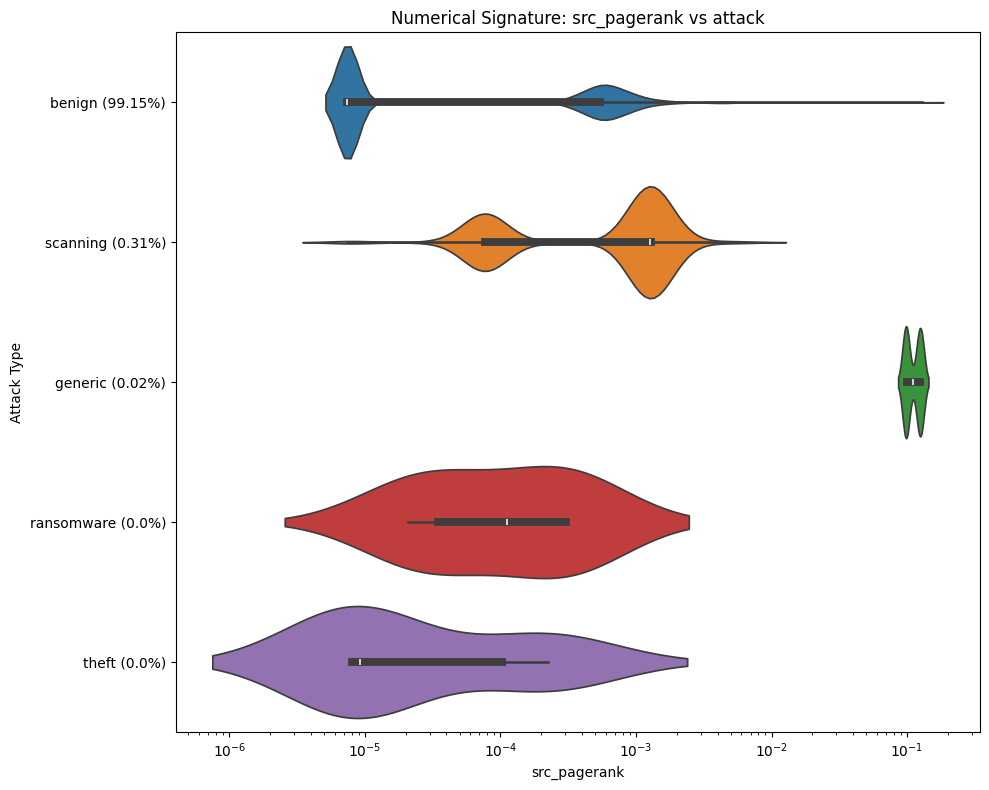

src_pagerank has MINIMAL ASSOCATION with attack!


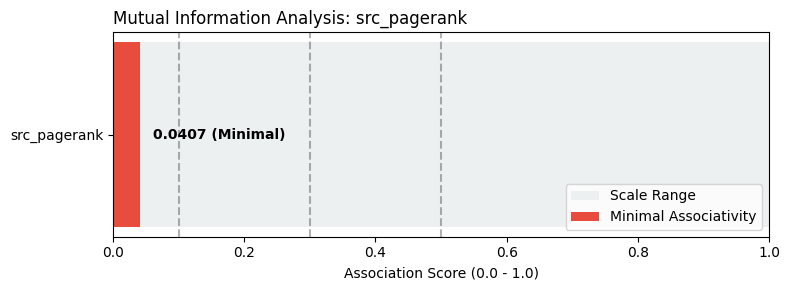

In [15]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'src_pagerank')

---
##### Explore dst_pagerank

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- Minimal association
- Denotes unique node and graph interactions

dst_pagerank IS statistically significant with attack!
Statistic: 2398.6558
P-Val: 0.0000
P-Threshold: 0.0500



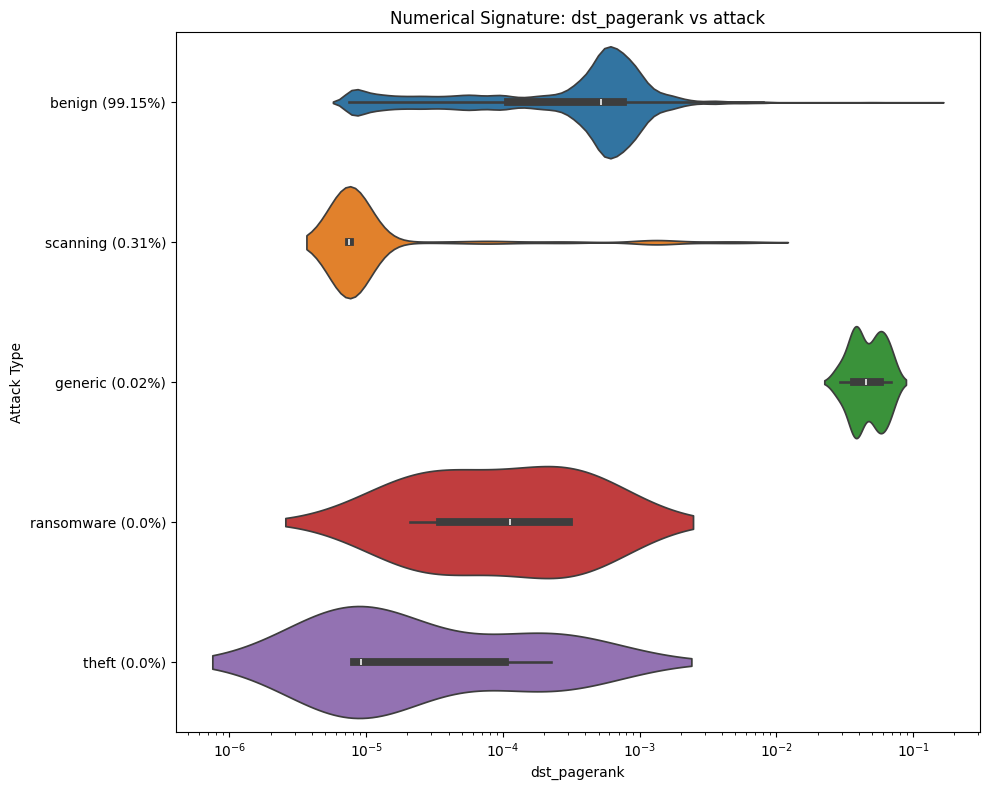

dst_pagerank has MINIMAL ASSOCATION with attack!


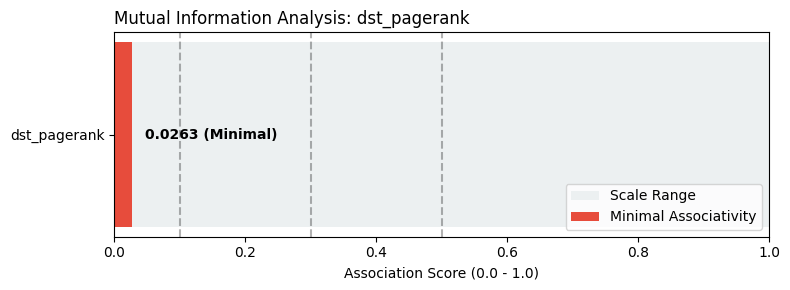

In [16]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'dst_pagerank')

---
##### Explore global_convergence_steps

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association
- Denotes unique graph topology

global_convergence_steps IS statistically significant with attack!
Statistic: 157012.1764
P-Val: 0.0000
P-Threshold: 0.0500


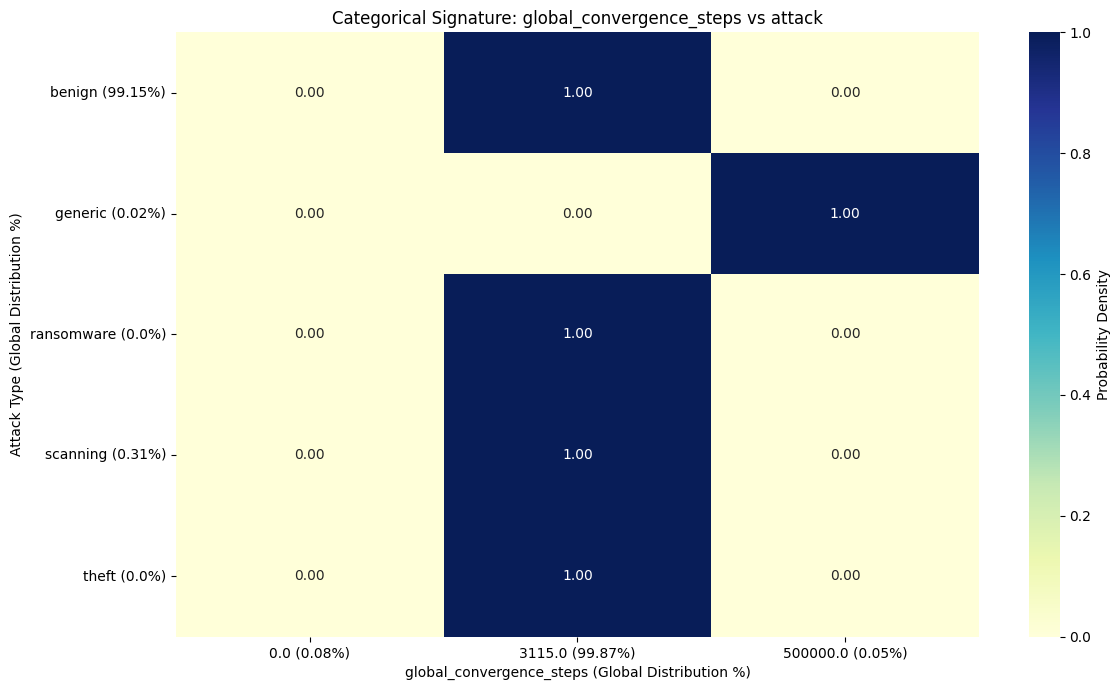

global_convergence_steps has HIGH ASSOCIATION with attack!


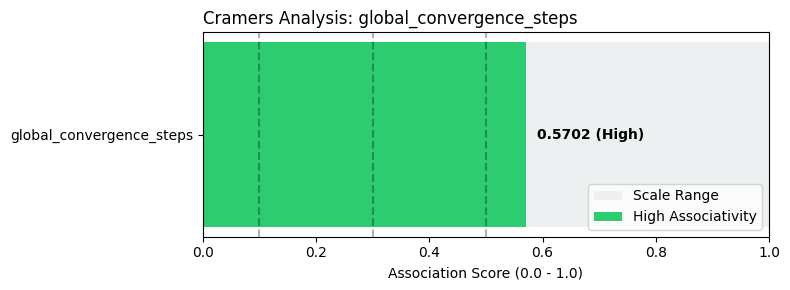

In [11]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'global_convergence_steps', is_object_feature=True)

---
##### Explore node_convergence_steps

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- Denotes node and graph topology relationship
- Minimal association

node_convergence_steps IS statistically significant with attack!
Statistic: 4667.4685
P-Val: 0.0000
P-Threshold: 0.0500



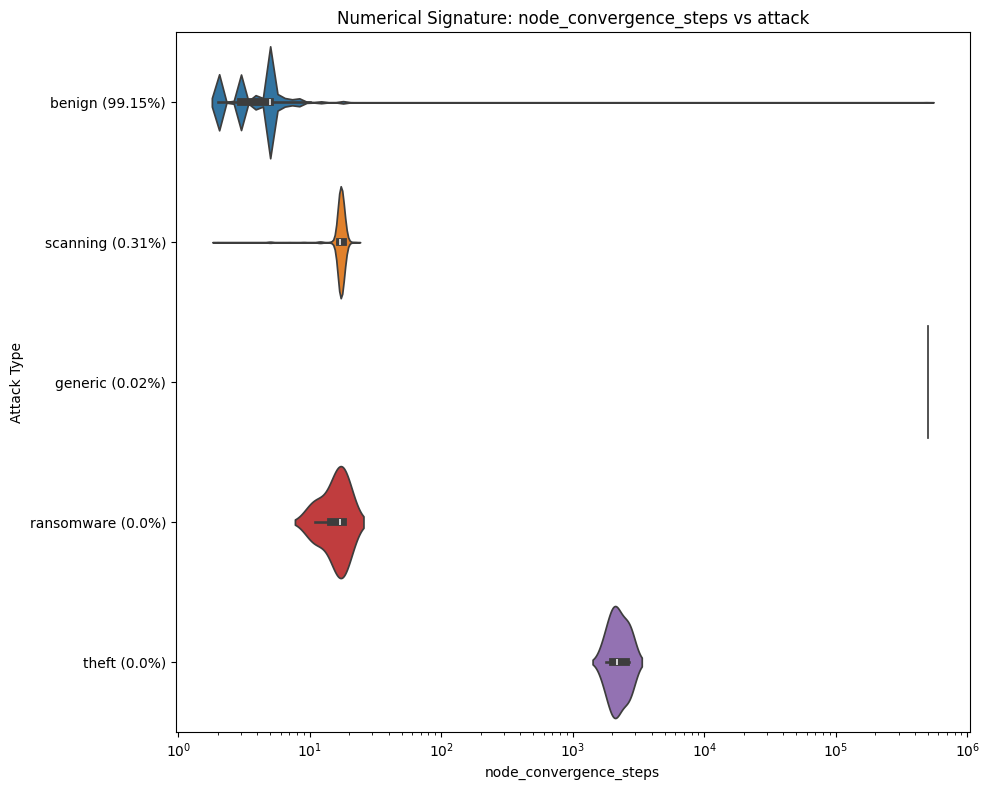

node_convergence_steps has MINIMAL ASSOCATION with attack!


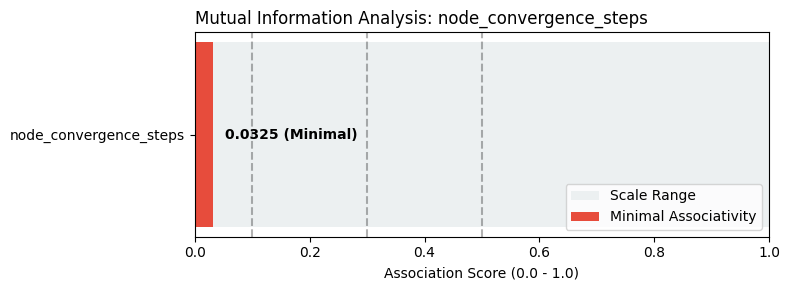

In [12]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'node_convergence_steps')

---
##### Explore spectral_gap

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association
- Denotes unique graph topology

spectral_gap IS statistically significant with attack!
Statistic: 157012.1764
P-Val: 0.0000
P-Threshold: 0.0500


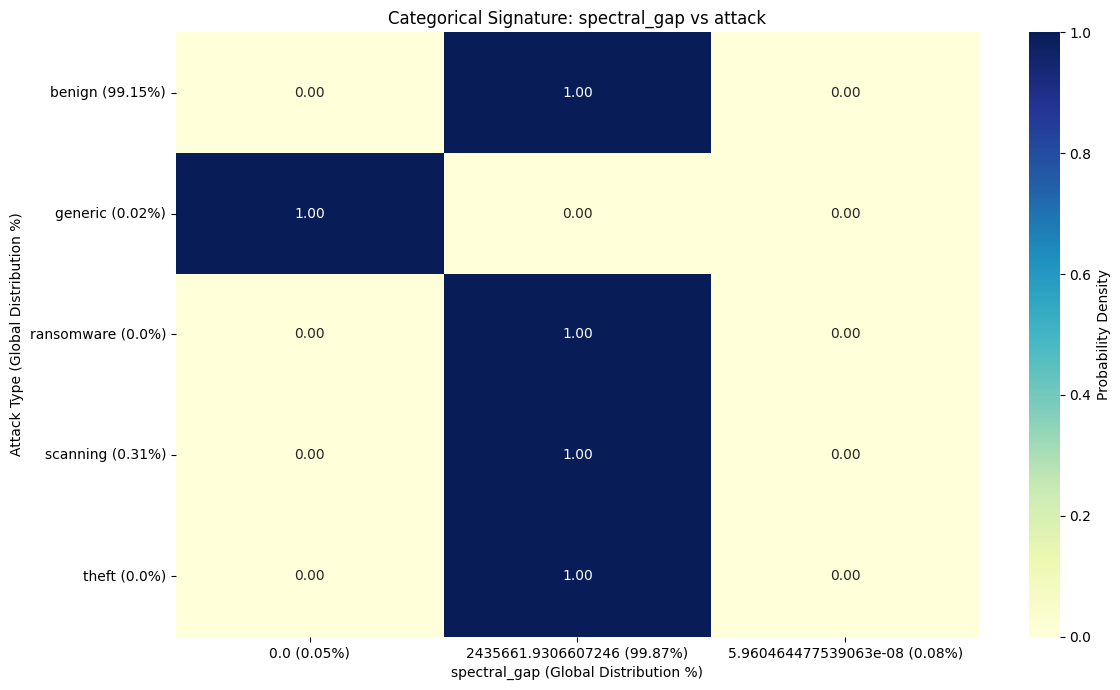

spectral_gap has HIGH ASSOCIATION with attack!


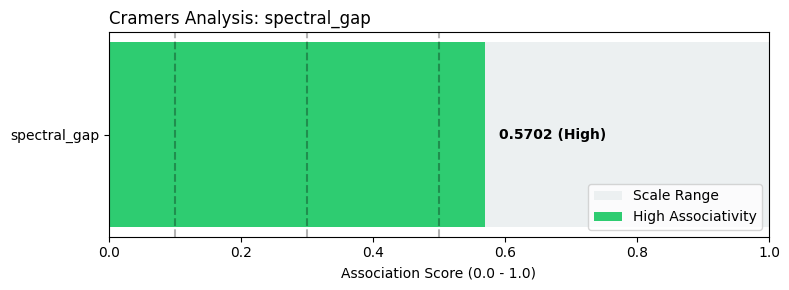

In [18]:
eND.analyze_statistical_significance_and_associativity(clean_df, 'spectral_gap', is_object_feature=True)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Final Data Dictionary

- [Back to Table of Contents](#table-of-contents)

</div>

In [2]:
clean_df = pd.read_parquet('datasets/clean_complex.parquet')

In [3]:
# First lets normalize and scale cols where necessary
normalized_df = eCN.preprocess_complex_data(clean_df)

In [4]:
# Export the fully prepared dataset for model training and testing
normalized_df.to_parquet('datasets/prepared_complex.parquet')

In [5]:
normalized_df

,source_ip,destination_ip,edge_weight,is_star_graph,is_chain_graph,is_bridge_link,attack,graph_id,baseline_edge_weight_ratio,baseline_edge_weight_zscore,eigen_1,eigen_2,v1_src,v2_src,src_pagerank,dst_pagerank,global_convergence_steps,node_convergence_steps,spectral_gap,target
0,0.147.57.10,192.168.1.194,-1.812574,0,1,1,benign,0,-0.492879,-0.024022,0.039844,0.039826,-0.046817,-0.046299,0.0,0.046522,-0.002568,-0.799600,0.047133,2
1,0.172.182.111,192.168.1.152,-1.812574,0,1,1,benign,0,-0.492879,-0.024022,0.039844,0.039826,-0.046817,-0.046299,0.0,0.026884,-0.002568,-0.799600,0.047133,2
2,0.30.150.52,192.168.1.194,-1.812574,0,1,1,benign,0,-0.492879,-0.024022,0.039844,0.039826,-0.046817,-0.046299,0.0,0.046522,-0.002568,-0.799600,0.047133,2
3,0.33.254.157,192.168.1.194,-1.812574,0,1,1,benign,0,-0.492879,-0.024022,0.039844,0.039826,-0.046817,-0.046299,0.0,0.046522,-0.002568,-0.799600,0.047133,2
4,0.70.81.77,192.168.1.194,-1.812574,0,1,1,benign,0,-0.492879,-0.024022,0.039844,0.039826,-0.046817,-0.046299,0.0,0.046522,-0.002568,-0.799600,0.047133,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241356,99.52.70.143,192.168.1.194,-1.812574,0,1,1,benign,0,-0.492879,-0.024022,0.039844,0.039826,-0.046817,-0.046299,0.0,0.046522,-0.002568,-0.799600,0.047133,2
241357,99.57.32.100,172.31.65.56,0.753710,0,1,1,benign,0,0.123681,-0.018521,0.039844,0.039826,-0.046817,-0.046299,0.0,0.013278,-0.002568,-0.046111,0.047133,2
241358,99.60.19.158,172.31.65.56,0.232602,0,1,1,benign,0,-0.275025,-0.022239,0.039844,0.039826,-0.046817,-0.046299,0.0,0.013278,-0.002568,-0.375257,0.047133,2
241359,99.70.241.225,172.31.66.38,-1.495323,0,1,1,benign,0,-0.490083,-0.024000,0.039844,0.039826,-0.046817,-0.046299,0.0,0.004101,-0.002568,-0.799600,0.047133,2


| Feature Name | Dtype | Example | Description |
| :--- | :--- | :--- | :--- |
| **source_ip** | `str` | 0.147.57.10 | Unique identifier for the originating node; removed during training to prevent IP-based overfitting. |
| **destination_ip** | `str` | 192.168.1.194 | Unique identifier for the receiving node; removed during training to ensure behavioral-only learning. |
| **edge_weight** | `float64` | -1.812574 | Standardized, log-scaled traffic magnitude (bytes/duration) representing connection intensity. |
| **is_star_graph** | `int64` | 0, 1 | Boolean flag: 1 if the flow belongs to a centralized hub-and-spoke topology. |
| **is_chain_graph** | `int64` | 1, 0 | Boolean flag: 1 if the flow is part of a sequential multi-hop path (lateral movement). |
| **is_bridge_link** | `int64` | 1, 0 | Boolean flag: 1 if this edge is a critical connector between two distinct graph islands. |
| **attack** | `str` | benign, ddos | Ground-truth security classification; the target variable for multiclass categorization. |
| **graph_id** | `int64` | 0, 1, 2 | Unique identifier for the discrete graph island; used for stratified group-splitting. |
| **baseline_edge_weight_ratio** | `float64` | -0.492878 | Standardized intensity ratio relative to historical benign benchmarks for this topology. |
| **baseline_edge_weight_zscore** | `float64` | -0.024022 | Standardized statistical distance of the flow weight from the benign mean. |
| **eigen_1** | `float64` | 0.039844 | Standardized principal eigenvalue; represents the total aggregate energy of the island. |
| **eigen_2** | `float64` | 0.039825 | Standardized second eigenvalue; measures structural complexity or secondary hub presence. |
| **v1_src** | `float64` | -0.046817 | Standardized component of the 1st eigenvector; denotes source IP's energy centrality. |
| **v2_src** | `float64` | -0.046298 | Standardized component of the 2nd eigenvector; denotes source IP's role in sub-cluster partitioning. |
| **src_pagerank** | `float64` | 0.077512 | Min-Max scaled influence score identifying the popularity/importance of the source IP. |
| **dst_pagerank** | `float64` | 0.046521 | Min-Max scaled influence score identifying the destination IP as a significant traffic sink. |
| **global_convergence_steps** | `float64` | 0.046543 | Global steps to convergence for a specific graph ID |
| **node_convergence_steps** | `float64` | -0.799600 | Node specific steps to convergence for a specific graph ID |
| **spectral_gap** | `float64` | 0.047133 | Standardized absolute difference between eigenvalues; measures centralization vs. mesh parity. |
| **target** | `int64` | 16, 2, 5 | Numerical integer mapping of the attack type identical to the normal data encoding. |